In [38]:
!pip install xgboost

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("../data/Customer_Churn.csv")

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

C:\Users\Mansi vaishya\AppData\Local\Temp\ipykernel_21692\2407051490.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [53]:
df["Monthly_to_Total"] = df["MonthlyCharges"] / (df["TotalCharges"] + 1)

df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"]
)

df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [54]:
df = pd.get_dummies(df, drop_first=True)

In [55]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [58]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [64]:
# Step 1: Train model
model.fit(X_train_res, y_train_res)

# Step 2: NOW paste your accuracy code here
from sklearn.metrics import accuracy_score

# Training accuracy
train_pred = model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, train_pred)

# Testing accuracy
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9156597390043499
Testing Accuracy: 0.8005677785663591


In [59]:
y_pred = model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8048261178140526

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      1036
           1       0.63      0.63      0.63       373

    accuracy                           0.80      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.80      0.80      0.80      1409



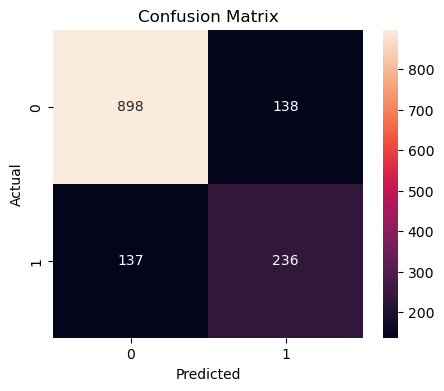

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
import pandas as pd

importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_df.head(10))

                               Feature  Importance
26                   Contract_Two year    0.260473
25                   Contract_One year    0.108438
11         InternetService_Fiber optic    0.071431
29      PaymentMethod_Electronic check    0.049700
13  OnlineSecurity_No internet service    0.040549
27                PaperlessBilling_Yes    0.034126
12                  InternetService_No    0.033578
15    OnlineBackup_No internet service    0.032164
24                 StreamingMovies_Yes    0.031866
14                  OnlineSecurity_Yes    0.027636


In [63]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)